# TP2 (a completer) : Arbre de decision — *Pima Diabetes*

Remplacez chaque `...` et chaque `# TODO`. Le corrige
(`../notebooks/TP2_arbre_decision.ipynb`) applique la **meme demarche sur un
AUTRE dataset (Breast Cancer)** : la structure est identique, seules les donnees
et les colonnes changent : a vous d'adapter.

**Objectif.** Predire si une patiente est **diabetique** avec un arbre
**interpretable**, et evaluer en privilegiant le **rappel sur les cas diabetiques**.

In [113]:
# Cellule fournie : a executer telle quelle.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NAVY, ACCENT, GRAY = "#16284D", "#0EA5E9", "#5B6679"
RED = "#C0504D"
PALETTE = [ACCENT, NAVY, "#F79646", "#3FA45B", RED]
plt.rcParams.update({
    "figure.figsize": (7, 4.5), "font.size": 12,
    "axes.titlecolor": NAVY, "axes.titleweight": "bold",
    "axes.edgecolor": GRAY, "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.width", 120)
print("Environnement pret.")

Environnement pret.


## Etape 0 : charger les donnees (fournie)

In [114]:
from sklearn.datasets import fetch_openml
ds = fetch_openml(name="diabetes", version=1, as_frame=True)   # telecharge une fois puis cache
X = ds.data                                  # 8 mesures medicales (preg, plas, pres, ...)
y = (ds.target == "tested_positive").astype(int)
CLASSES = ["non_diabetique", "diabetique"]   # 0 = negatif, 1 = positif
print(X.shape, CLASSES)

(768, 8) ['non_diabetique', 'diabetique']


## 1. Exploration
**Consigne.** Affichez la repartition des classes (combien de diabetiques / non).

In [115]:
# TODO : repartition de y (indice : value_counts + map vers CLASSES)
y_repartition = y.map(lambda x: CLASSES[x])
y_repartition.value_counts()

class
non_diabetique    500
diabetique        268
Name: count, dtype: int64

## 2. Modelisation
**Consigne.** Separez en train/test (25% test, `stratify=y`, `random_state=42`),
puis entrainez un `DecisionTreeClassifier` (`max_depth=3`, `min_samples_leaf=10`).

In [116]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

arbre = DecisionTreeClassifier(max_depth=3, min_samples_leaf=10,criterion="gini", random_state=0)        # TODO : creer et entrainer l'arbre
arbre.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

## 3. Evaluation
**Consigne.** Affichez l'accuracy train et test, le `classification_report`
(avec `target_names=CLASSES`) et la **matrice de confusion**. Commentez le
**rappel** de la classe `diabetique`.

Accuracy train : 0.783
Accuracy test  : 0.714
                precision    recall  f1-score   support

non_diabetique      0.750     0.840     0.792       125
    diabetique      0.615     0.478     0.538        67

      accuracy                          0.714       192
     macro avg      0.683     0.659     0.665       192
  weighted avg      0.703     0.714     0.704       192



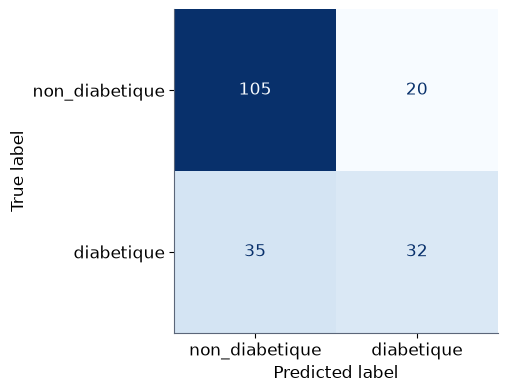

In [117]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# TODO : accuracy train / test
print(f"Accuracy train : {arbre.score(X_train, y_train):.3f}")
print(f"Accuracy test  : {arbre.score(X_test, y_test):.3f}")
y_pred = arbre.predict(X_test)
# TODO : afficher classification_report
print(classification_report(y_test, y_pred, target_names=CLASSES, digits=3))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4.2))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap="Blues", colorbar=False)
plt.show()

## 4. Visualisation
**Consigne.** Tracez l'arbre (`plot_tree`) puis l'**importance des variables**
(barres horizontales des `feature_importances_` non nulles).

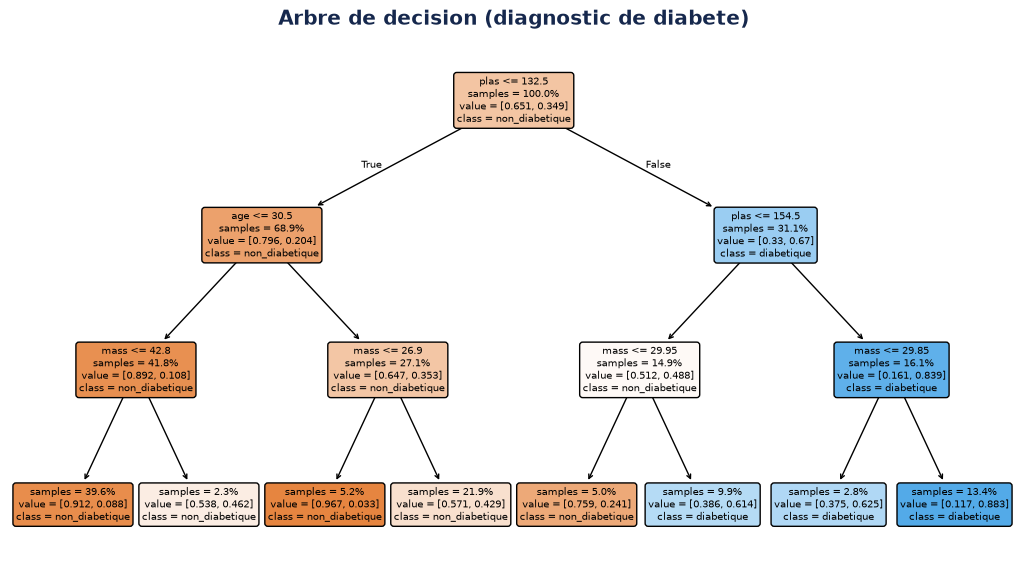

In [118]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(13, 7))
# TODO : plot_tree(arbre, feature_names=..., class_names=CLASSES, filled=True, ...)
plot_tree(arbre, feature_names=list(X.columns), class_names=CLASSES, filled=True,
          rounded=True, impurity=False, proportion=True, ax=ax)
ax.set_title("Arbre de decision (diagnostic de diabete)")
plt.show()

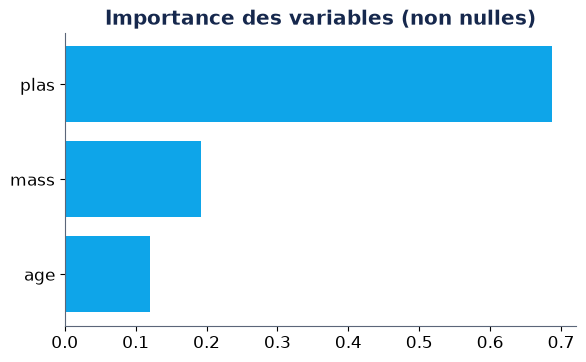

In [119]:
imp = pd.Series(arbre.feature_importances_, index=X.columns)
imp = imp[imp > 0].sort_values()
# TODO : barh de imp
fig, ax = plt.subplots(figsize=(6.6, 3.8))
ax.barh(imp.index, imp.values, color=ACCENT)
ax.set_title("Importance des variables (non nulles)")
plt.show()


## 5. Prise de decision
**Consigne.** Sur 5 cas du test, affichez diagnostic reel, predit et
`predict_proba` de la classe diabetique.

In [120]:
ech = X_test.head(5)
# TODO : pred et proba, puis DataFrame comparatif
pred = arbre.predict(ech)
proba = arbre.predict_proba(ech)[:, 1]
pd.DataFrame({
    "reel": [CLASSES[v] for v in y_test.head(5)],
    "predit": [CLASSES[p] for p in pred],
    "proba_benin": proba.round(2),
})

,reel,predit,proba_benin
0,diabetique,non_diabetique,0.43
1,non_diabetique,non_diabetique,0.09
2,non_diabetique,non_diabetique,0.09
3,diabetique,diabetique,0.61
4,diabetique,diabetique,0.88


## A rendre
- Accuracy test + lecture de la matrice de confusion.
- Le rappel sur `diabetique` et pourquoi il est prioritaire ici.
- Les 2-3 variables les plus determinantes.

**Bonus.** Faites varier `max_depth` (2, 3, 6, None) : ou commence le surapprentissage ?

# Random Forest

## 1. Modelisation

In [121]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

rf = RandomForestClassifier( max_depth=3, min_samples_leaf=5, random_state=42)
rf.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

## 2. Evaluation

Accuracy - Train: 0.7951388888888888
Accuracy - Test: 0.7291666666666666
              precision    recall  f1-score   support

           0       0.75      0.87      0.81       125
           1       0.66      0.46      0.54        67

    accuracy                           0.73       192
   macro avg       0.71      0.67      0.68       192
weighted avg       0.72      0.73      0.72       192



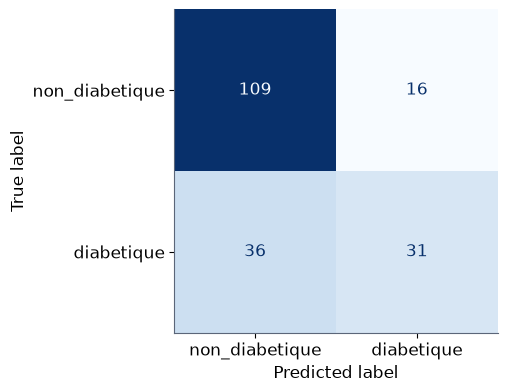

In [122]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)
print("Accuracy - Train:", rf.score(X_train, y_train))
print("Accuracy - Test:", rf.score(X_test, y_test))

print(classification_report(y_test, y_pred_test))
cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(5, 4.2))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap="Blues", colorbar=False)
plt.show()

## 3. Visualisation

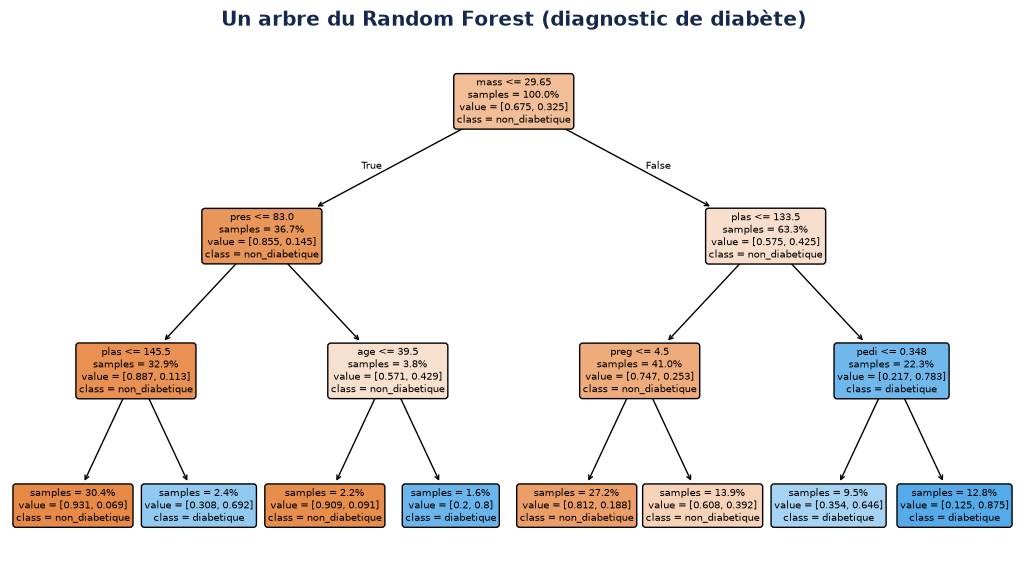

In [123]:
from sklearn.tree import plot_tree

arbre_rf = rf.estimators_[0]

fig, ax = plt.subplots(figsize=(13, 7))

plot_tree(arbre_rf,feature_names=list(X.columns),class_names=CLASSES,filled=True,rounded=True,impurity=False,proportion=True,ax=ax)

ax.set_title("Un arbre du Random Forest (diagnostic de diabète)")
plt.show()

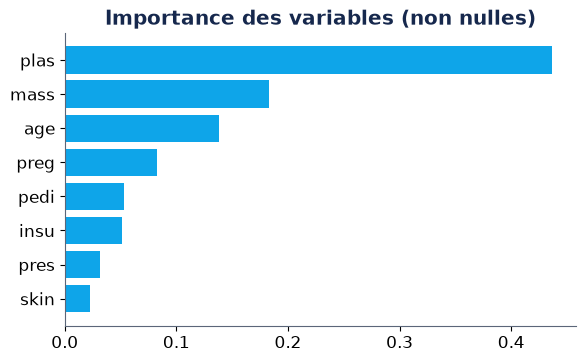

In [124]:
imp = pd.Series(rf.feature_importances_, index=X.columns)
imp = imp[imp > 0].sort_values()

fig, ax = plt.subplots(figsize=(6.6, 3.8))
ax.barh(imp.index, imp.values, color=ACCENT)
ax.set_title("Importance des variables (non nulles)")
plt.show()

## 4. Prise de décision

In [125]:
ech = X_test.head(5)

pred = rf.predict(ech)
proba = rf.predict_proba(ech)[:, 1]
pd.DataFrame({
    "reel": [CLASSES[v] for v in y_test.head(5)],
    "predit": [CLASSES[p] for p in pred],
    "proba_benin": proba.round(2),
})

,reel,predit,proba_benin
0,diabetique,non_diabetique,0.40
1,non_diabetique,non_diabetique,0.33
2,non_diabetique,non_diabetique,0.20
3,diabetique,non_diabetique,0.46
4,diabetique,diabetique,0.70


# XGBoost

## 1. Modelisation

In [126]:
from sklearn.ensemble import GradientBoostingClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

clf = GradientBoostingClassifier(max_depth=3, min_samples_leaf=5, random_state=42)
clf.fit(X_train, y_train)

,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

## 2. Evaluation

Accuracy - Train: 0.9149305555555556
Accuracy - Test: 0.75
              precision    recall  f1-score   support

           0       0.79      0.84      0.81       125
           1       0.66      0.58      0.62        67

    accuracy                           0.75       192
   macro avg       0.73      0.71      0.72       192
weighted avg       0.74      0.75      0.75       192



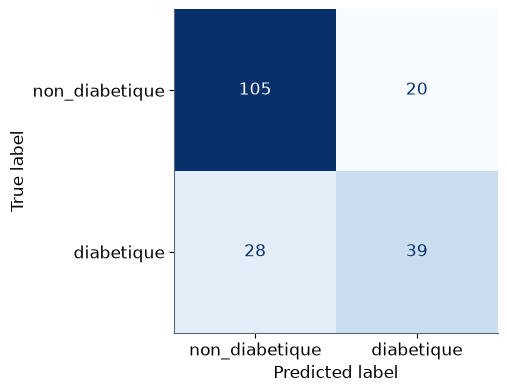

In [127]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)
print("Accuracy - Train:", clf.score(X_train, y_train))
print("Accuracy - Test:", clf.score(X_test, y_test))

print(classification_report(y_test, y_pred_test))
cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(5, 4.2))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap="Blues", colorbar=False)
plt.show()

## 3. Visualisation

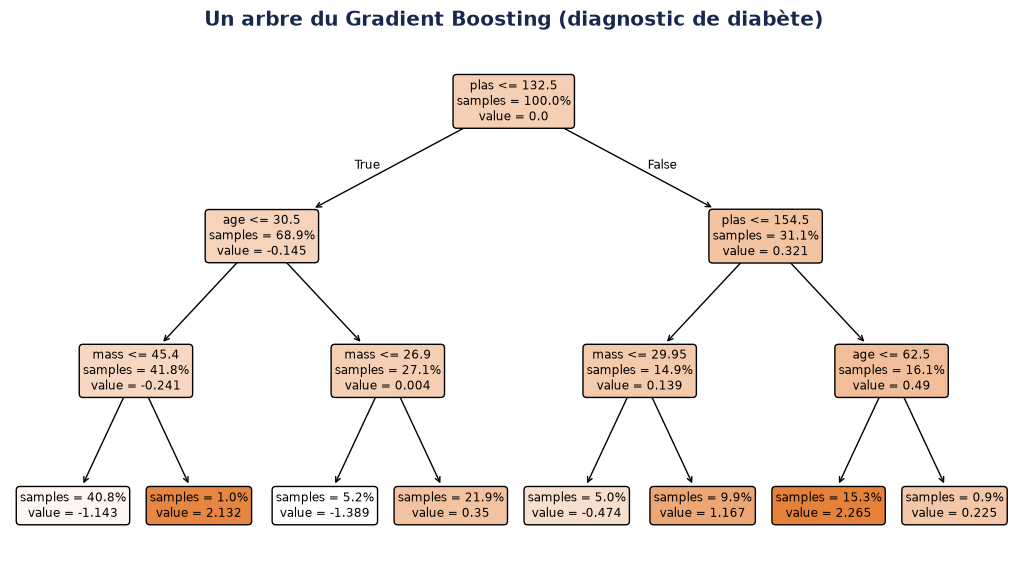

In [128]:
from sklearn.tree import plot_tree

arbre_clf = clf.estimators_[0][0]

fig, ax = plt.subplots(figsize=(13, 7))

plot_tree(arbre_clf,feature_names=list(X.columns),class_names=CLASSES,filled=True,rounded=True,impurity=False,proportion=True,ax=ax)

ax.set_title("Un arbre du Gradient Boosting (diagnostic de diabète)")
plt.show()


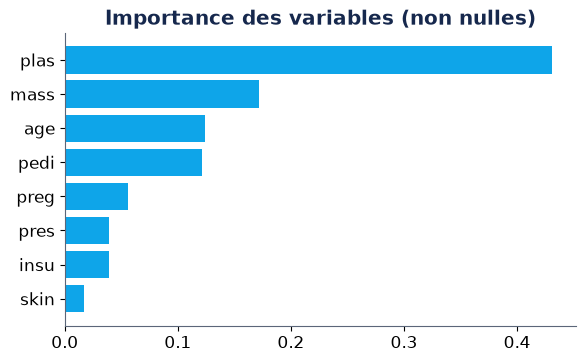

In [129]:
imp = pd.Series(clf.feature_importances_, index=X.columns)
imp = imp[imp > 0].sort_values()

fig, ax = plt.subplots(figsize=(6.6, 3.8))
ax.barh(imp.index, imp.values, color=ACCENT)
ax.set_title("Importance des variables (non nulles)")
plt.show()

## 4. Prise de décision

In [130]:
ech = X_test.head(5)

pred = clf.predict(ech)
proba = clf.predict_proba(ech)[:, 1]
pd.DataFrame({
    "reel": [CLASSES[v] for v in y_test.head(5)],
    "predit": [CLASSES[p] for p in pred],
    "proba_benin": proba.round(2),
})

,reel,predit,proba_benin
0,diabetique,non_diabetique,0.27
1,non_diabetique,non_diabetique,0.40
2,non_diabetique,non_diabetique,0.05
3,diabetique,non_diabetique,0.21
4,diabetique,diabetique,0.87
